# California Housing

## vediamo una tipica pipeline di pre-analisi di un dataset

# Passo 0: carica dataset

In [2]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Access the features (X) and target (y)
df = housing.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# Passo 1: applica describe() al dataset

In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Cosa controllare in un dataset dopo il describe()?

1. controllare che min e max hanno senso (AveRooms e AveOccup hanno min e max fuori scala)
2. controlla rapporto tra media e devStd. se è >1 c'è forte dispersione di dati su quella colonna (AveOccup e Population hanno dispersione)
3. controlla media e mediana (50%) sono simili tra loro. se non lo sono abbiamo una distribuzione chiamata skewed (la media è piu bassa del 50%, quindi la distribuzione dei dati è spostata piu a sx)
    come aggiustare? si raggruppano i dati in sezioni per trasformare la scala esponenziale in lineare, distribuisci in sottosezioni di lunghezza esponenziale. (piu è alta la campana in quella porzione, piu stretta sarà la porzione. piu bassa sarà la campana, piu larga sarà la sezione)
    |   |       |              |                            |
    si applica il logaritmo, cosi verranno bilanciate le distanze

    

# Passo 2: applica info()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Cosa controllare dopo info()?

 ### 1. controllare le colonne che hanno Null (None). come li gestisco?

    - se i null < 5% rimuovo le righe nulle. sono molto poche, non le gestisco, le rimuovo e basta
    - se i null < 15%/20%, sostituisco con media i numeri e moda le stringhe
    - se i null > 20% o elimino la colonna o creo un modello di ML per predirne i valori

### Sostituzione con media 

immaginiamo un dataset con età e guadagno. ho il 10% di null sul guadagno. come faccio?
raggruppo in fasce d'età, faccio la media per fasce e sostituisco le medie dei guadagni al posto dei null per fascia d'età associata.
se c'è un valore che mi aiuta a raffruppare, meglio questo approccio che fare la media su tutta la colonna guadangno. rispecchia meglio la realtà.


### 2. controllare le colonne che non sono numeri (non possiamo fare operazioni se sono stringhe)

### 3. gestire gli outliers

possono essere di 2 tipi:
- statistici (es. persona alta 2,30 metri, raro ma plausibile)
- errori (es. persona alta 23 metri. errore)

(continua a leggere per la gestione)



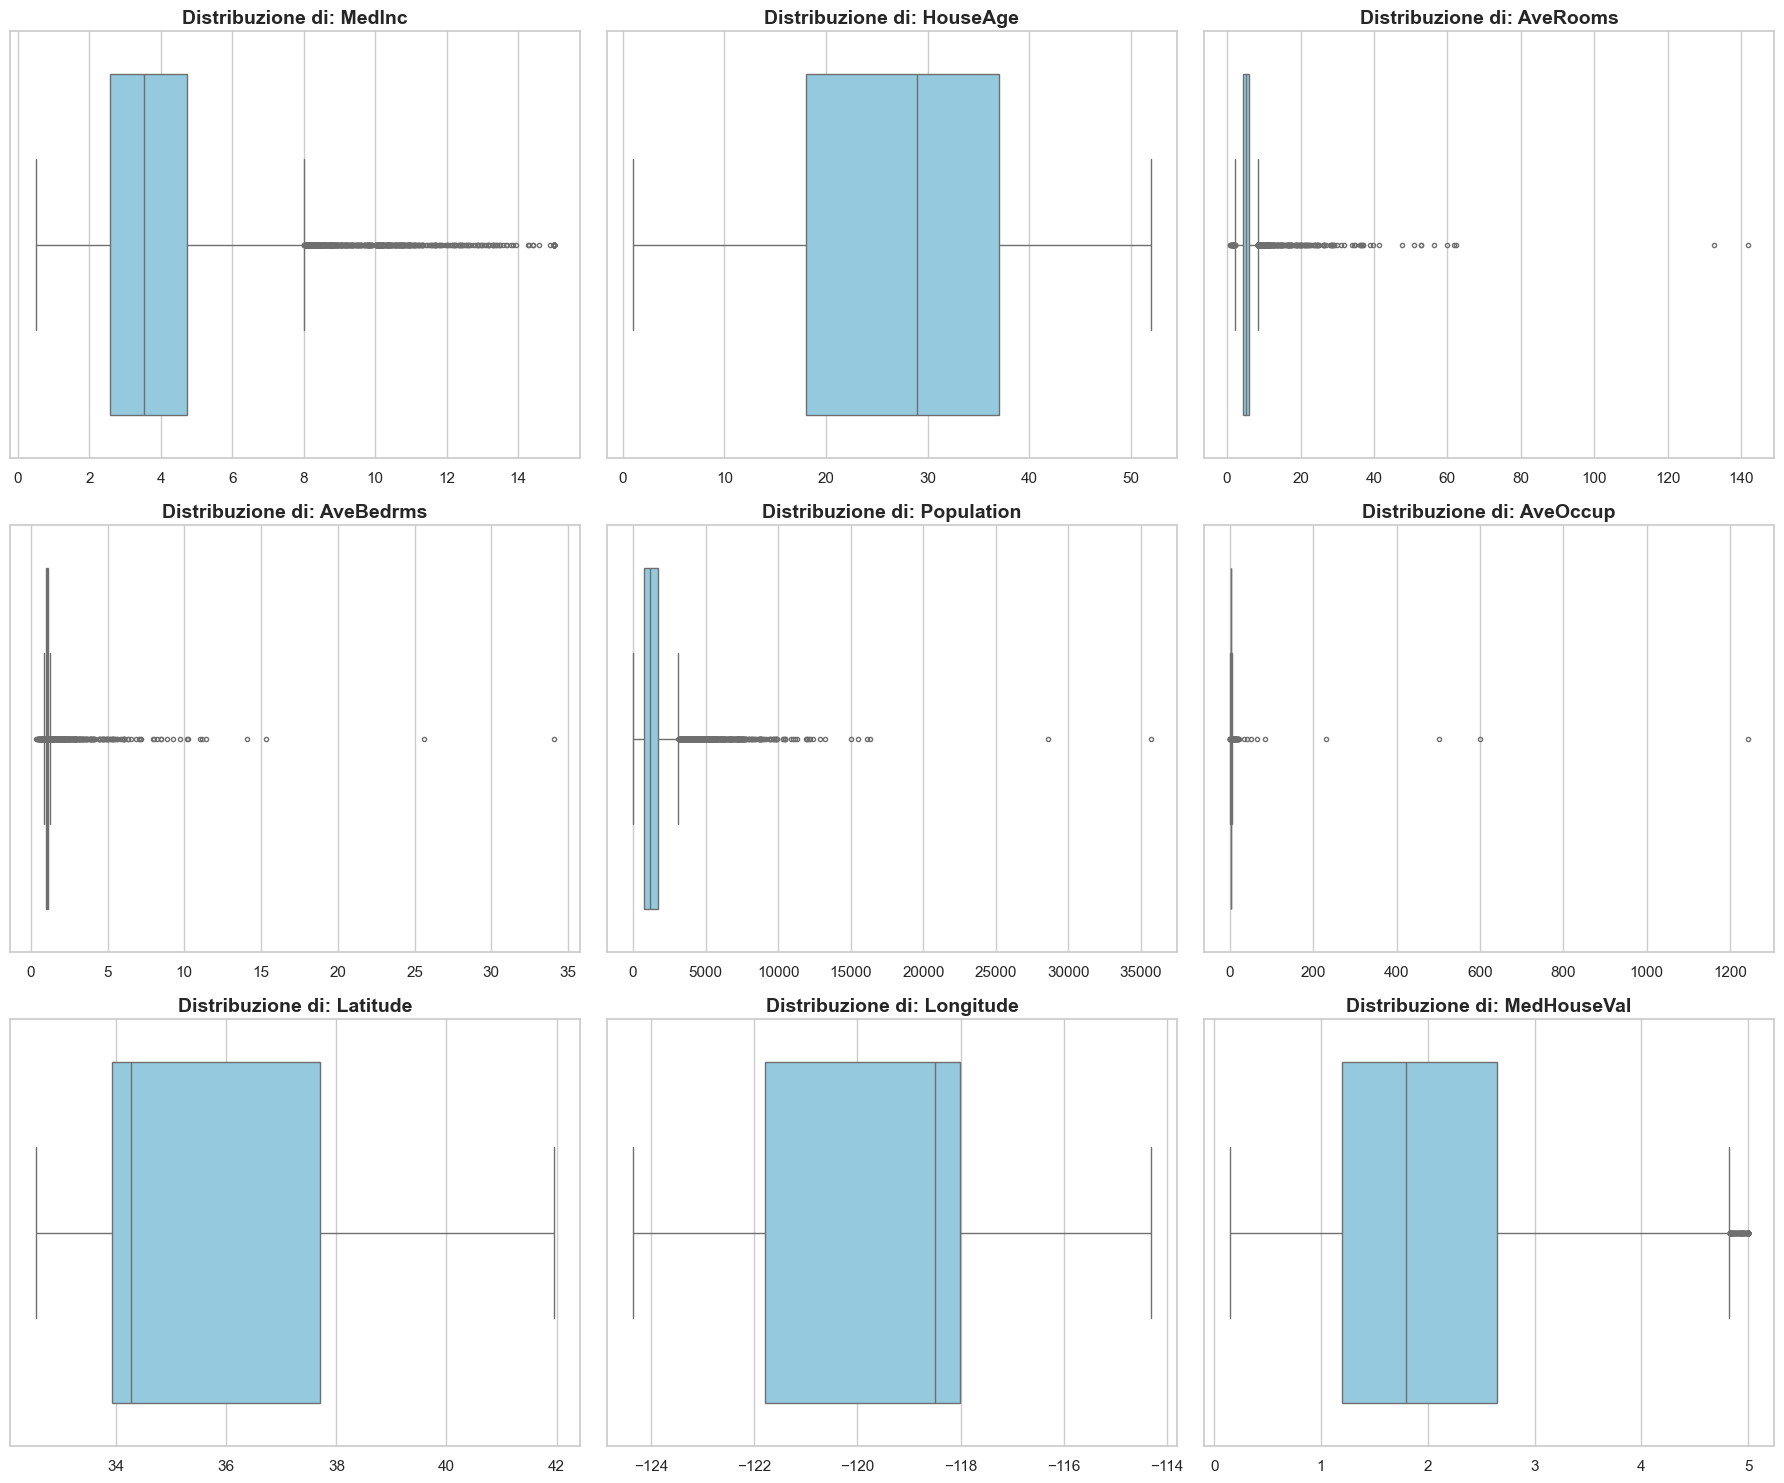

In [5]:
# Grafico BoxPlot. leggi descrizione per saperne di più
"""
BoxPlot. 
Individuare gli outlier è una fase fondamentale dell’analisi esplorativa dei dati (EDA).
Un outlier è un’osservazione che si discosta in modo significativo dal comportamento
generale del dataset.

Trovare questi valori serve principalmente a tre scopi:

1) Qualità del dato
   Un valore anomalo può essere il risultato di un errore di misurazione,
   di inserimento o di acquisizione.

2) Comprensione del fenomeno
   A volte l’outlier rappresenta un evento raro ma reale,
   che può avere un significato importante (ad esempio case di lusso
   in un dataset immobiliare).

3) Impatto sui modelli statistici
   Molti algoritmi (come regressione lineare, media e varianza)
   sono sensibili ai valori estremi. Pochi punti molto grandi o molto piccoli
   possono alterare significativamente i risultati.

Il boxplot è uno strumento grafico che permette di visualizzare in modo
sintetico la distribuzione di una variabile numerica.

Un boxplot mostra:

- La mediana (linea centrale nella scatola), che rappresenta il valore centrale.
- Il primo e terzo quartile (Q1 e Q3), che delimitano il 50% centrale dei dati.
- L’intervallo interquartile (IQR = Q3 - Q1), che misura la dispersione.
- I "baffi", che indicano l’estensione dei valori non anomali.
- Eventuali punti isolati, che rappresentano gli outlier.

Interpretare un boxplot significa osservare:

- La posizione della mediana → indica il valore tipico.
- La dimensione della scatola → misura la variabilità.
- La simmetria o asimmetria → suggerisce se la distribuzione è sbilanciata.
- La presenza di punti esterni → indica possibili valori anomali.

In sintesi, trovare gli outlier aiuta a comprendere meglio la struttura dei dati
e a decidere se mantenerli, correggerli o trattarli con tecniche specifiche.
Il boxplot fornisce una rappresentazione compatta e immediata di queste informazioni,
rendendolo uno strumento molto efficace nella fase iniziale dell’analisi.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile
sns.set_theme(style="whitegrid")

# Creiamo la griglia di subplot (3x3 adattabile)
num_colonne = len(df.columns)
righe = 3
colonne = 3

fig, axes = plt.subplots(nrows=righe, ncols=colonne, figsize=(18, 15))
axes = axes.flatten()

# Creazione boxplot per ogni colonna numerica
for i, col in enumerate(df.columns):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='skyblue',
        fliersize=3
    )
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuove eventuali subplot vuoti se le colonne sono meno di 9
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Passo 3: gestione outlier

## 1. Metodo IQR (Interquartile Range)

È la tecnica usata dai boxplot. Si basa sulla distanza tra il primo quartile ($Q_1$) e il terzo quartile ($Q_3$). Tutto ciò che cade fuori dall'intervallo $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ viene considerato outlier.


In [6]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Caricamento dati
df = fetch_california_housing(as_frame=True).frame

def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtraggio
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Applichiamolo solo ad alcune colonne critiche (es. MedInc e AveRooms)
df_iqr = remove_outliers_iqr(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con IQR: {len(df) - len(df_iqr)}")

Righe rimosse con IQR: 711


## 2. Metodo Z-Score (Deviazione Standard)

Questa tecnica si basa sulla distribuzione normale. Si calcola quanto un valore dista dalla media in termini di deviazioni standard ($\sigma$). La formula dello Z-score è:

$$Z = \frac{x - \mu}{\sigma}$$

Solitamente, un valore con uno Z-score maggiore di 3 o minore di -3 è considerato un outlier estremo (rappresenta meno dello 0.3% dei dati in una distribuzione normale).


In [7]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

Righe rimosse con Z-Score: 482


## nota
IGR è più aggressivo ma funziona bene anche su distribuzioni più sporche

Z-SCORE meno aggressivo ma funziona solo su dati distribuiti normalmente

# Passo 4: gestione colonne categoriche

- se la colonna è bianria (si/no) -> trasformiamo in 0/1
- se ho più variabili (Milano/Roma/Napoli) -> assegno ad ogni variabile un numero (Milano=1, Roma=2, Napoli=3)
ma potrebbe esserci il problema che con la nuova configurazione per il computer Milano+Roma=Napoli ...
non posso quindi applicarla su variabili scollegate 

se avessi piccolo/medio/grande che hanno un rapporto di grandezza potrei farlo, ma se sono scollegate (come le città) devo procedere diversamente

SOLUZIONE: creo una colonna binaria per ogni opzione! 
- is_Milano: true/false 
- is_Roma: true/false

Attenzione! se ho 100 opzioni, sto aggiungendo 100 dimensioni. potrebbe sembrare controproducente, ma meglio avere dimensioni piu che dati incosistenti

ci sono 2 tecniche per questi approcci

## 1. Label Encoding

Il LabelEncoder trasforma le stringhe in numeri progressivi ($0, 1, 2, ...$).

In [8]:
from sklearn.preprocessing import LabelEncoder

# Esempio: Target con tre classi
y = ['Basso', 'Medio', 'Alto', 'Basso', 'Alto']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classi originali: {le.classes_}")
print(f"Valori trasformati: {y_encoded}")
# Output: [1, 2, 0, 1, 0] (l'ordine è spesso alfabetico)

Classi originali: ['Alto' 'Basso' 'Medio']
Valori trasformati: [1 2 0 1 0]


## 2. One-Hot Encoding

Questa è la tecnica standard per le variabili categoriche senza un ordine intrinseco (es. "Colore", "Città"). Crea una nuova colonna binaria ($0$ o $1$) per ogni categoria.

In [9]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# DataFrame di esempio
df_test = pd.DataFrame({'Città': ['Roma', 'Milano', 'Napoli', 'Roma']})

# Inizializziamo l'encoder
# sparse_output=False serve per avere un array NumPy leggibile (non una matrice sparsa)
ohe = OneHotEncoder(sparse_output=False)

# Trasformazione
ohe_transformed = ohe.fit_transform(df_test[['Città']])

# Creiamo un nuovo DataFrame con i nomi delle colonne corretti
df_ohe = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(['Città']))

print(df_ohe)

   Città_Milano  Città_Napoli  Città_Roma
0           0.0           0.0         1.0
1           1.0           0.0         0.0
2           0.0           1.0         0.0
3           0.0           0.0         1.0


# Passo 5: distribuzioni incrociate

## visualizzo le distribuzioni delle colonne

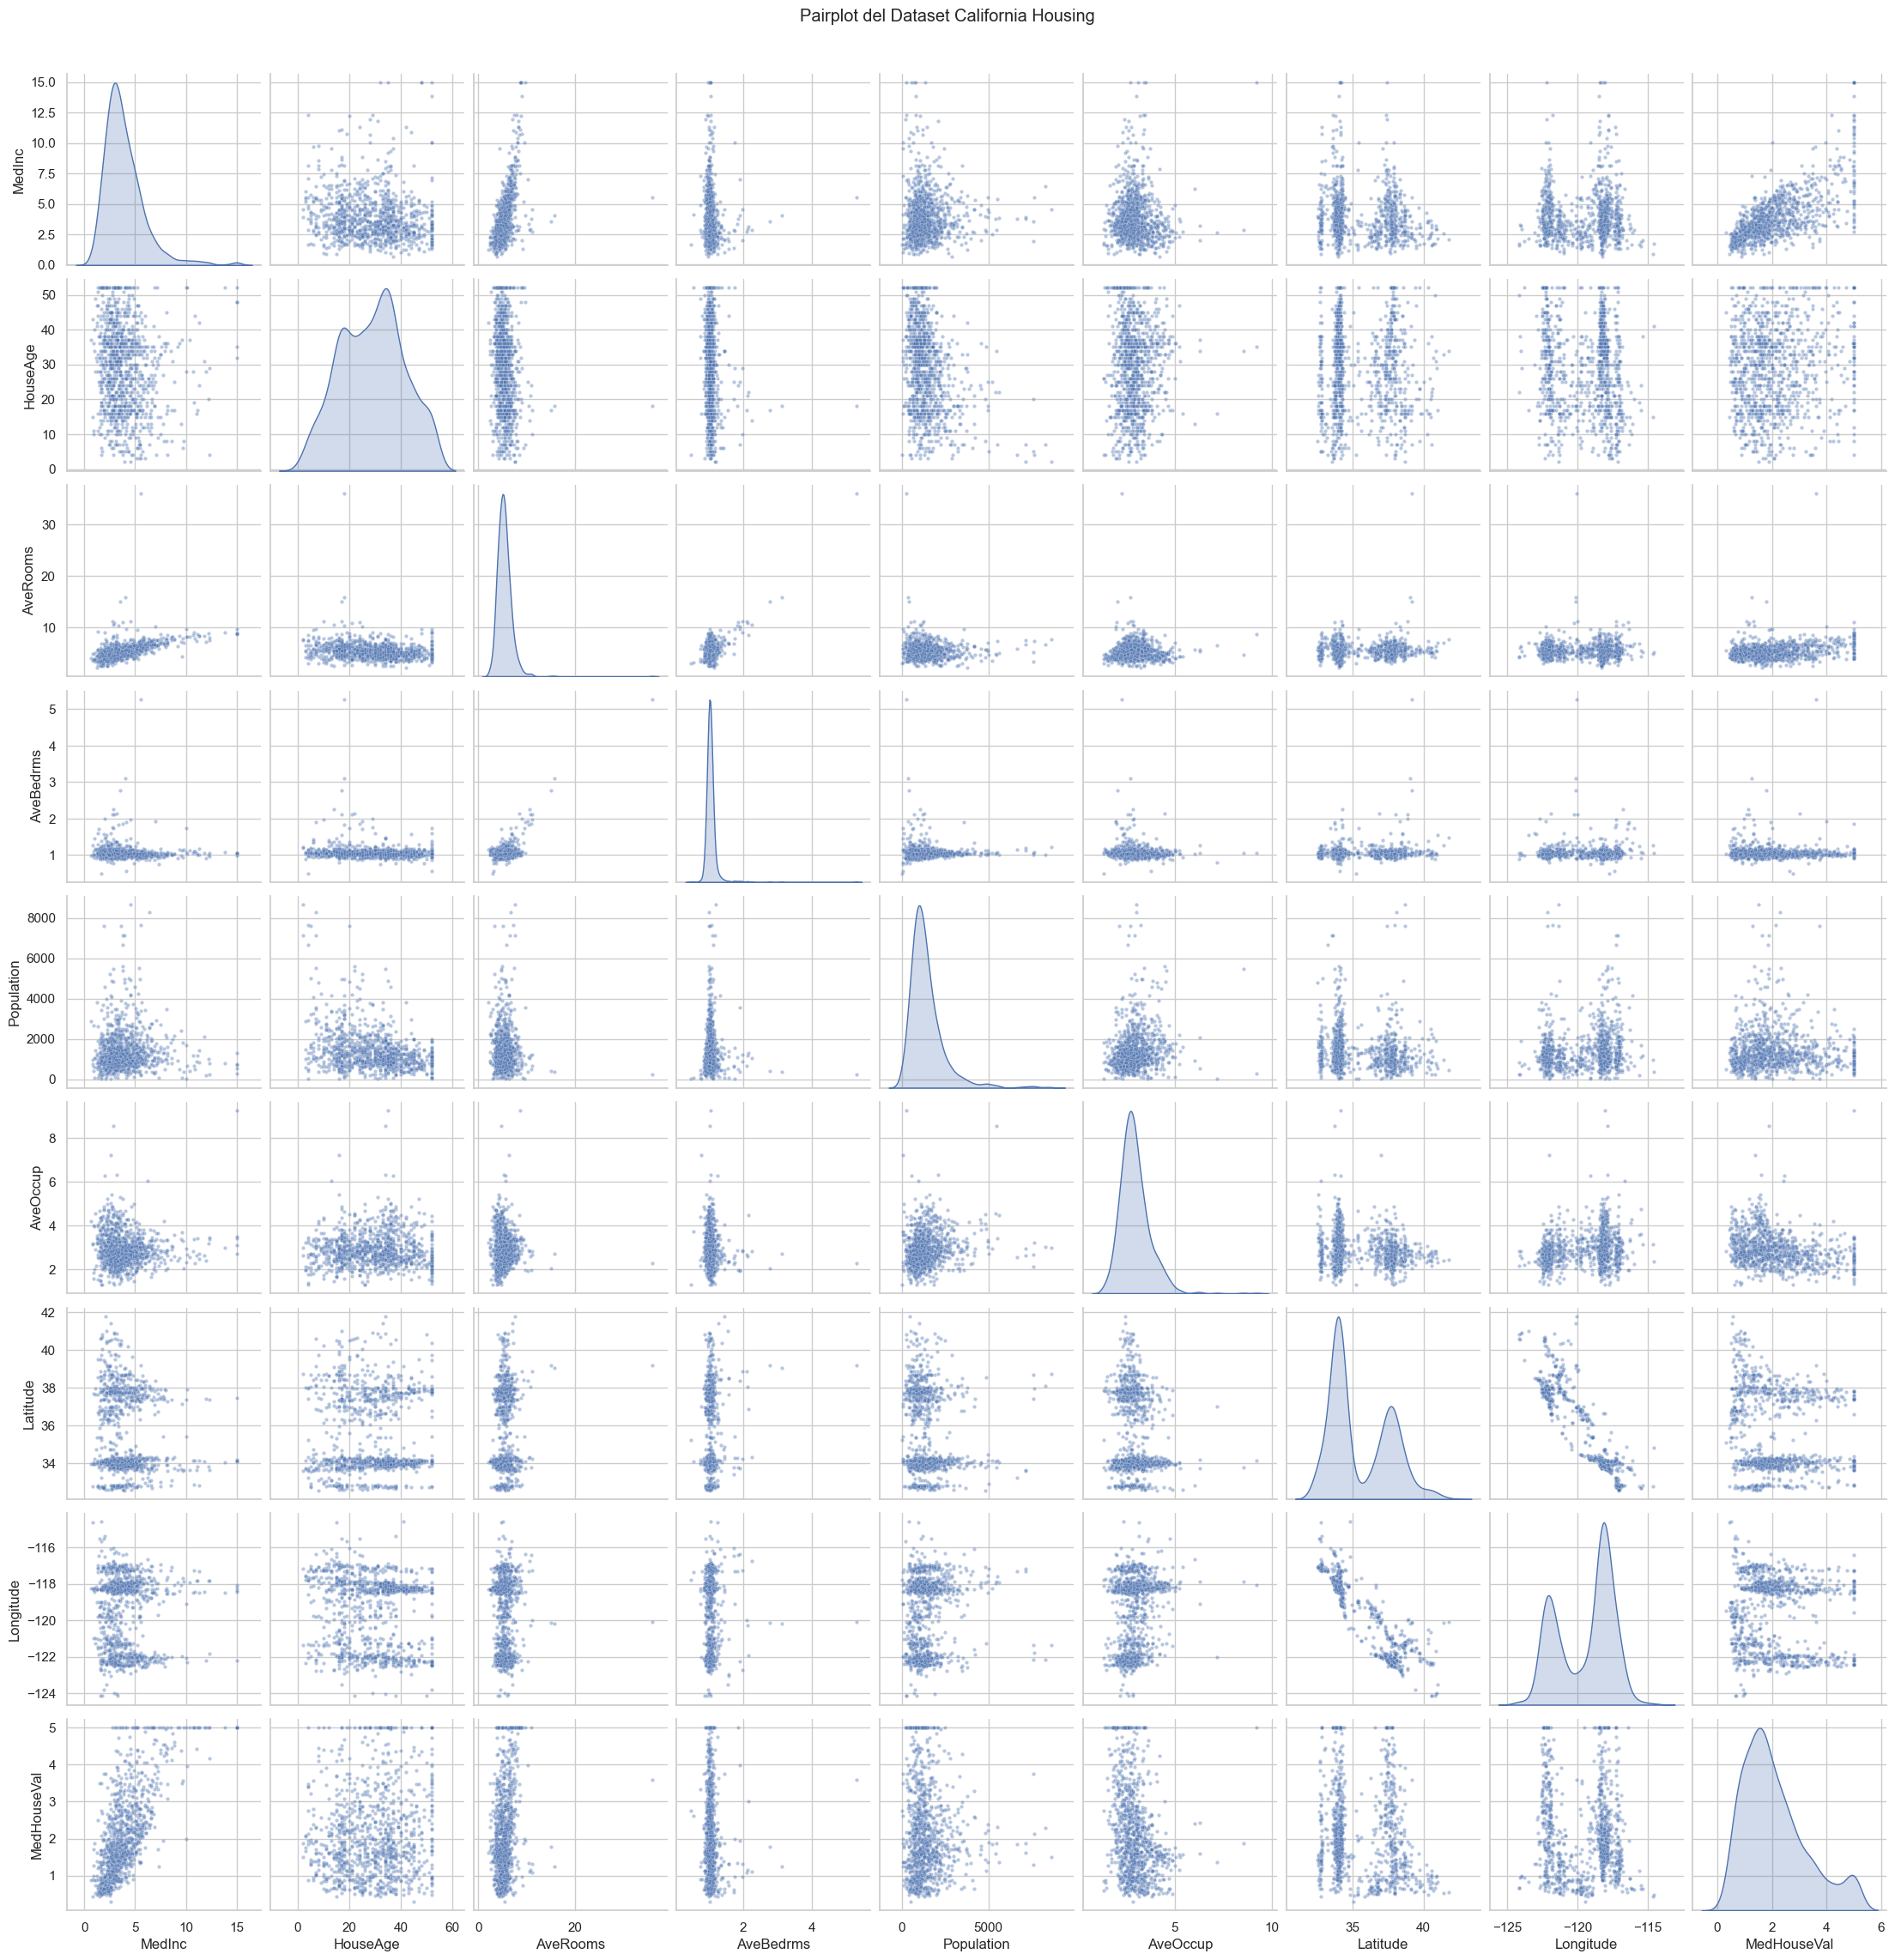

In [10]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
df_sample = df.sample(n=1000, random_state=42)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df_sample,
diag_kind='kde',
plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Housing", y=1.02)
plt.show()

## come interpreto? 

la diagonale è la distribuzione di se stessa, vediamo che alcune sono skewed, altre normali, altre doppie ecc 

- cerco casi di linearità, cerco tra le distribuzioni una forma "lineare" cosi so che quella riga e quella colonna sono linearmente dipendenti (se una aumenta, aumenta anche l'altra)

esempi
- vedo che MedHouseVal è linearmente dipendente da diverse colonne (quelle con una forma che ricorda una linea)
- vedo varibili lineari tra loro, soprattutto tra var Target e MedHouseVal
- vedo distribuzioni gaussiane, anche un po skewed, a cui applicherò una trasformazione logaritmica
- vedo il gradico tra lat e long e vedo (a parte la forma uguale alla california giustamente) picchi dovuti a San Francisco e Los Angeles

## Matrice di Correlazione

ottima per trovare variabili linearmente dipendenti tra loro 

sono interessanti tutte le correlazioni maggiori di +0.15 e inferiori a -0.15

ricorda:
- correlazione positiva -> andamenti simili (se una sale, l'altra sale)
- correlazione negativa -> andamenti opposti (se una sale, l'altra scende)

ATTENZIONE: correlazione non è causalità. 

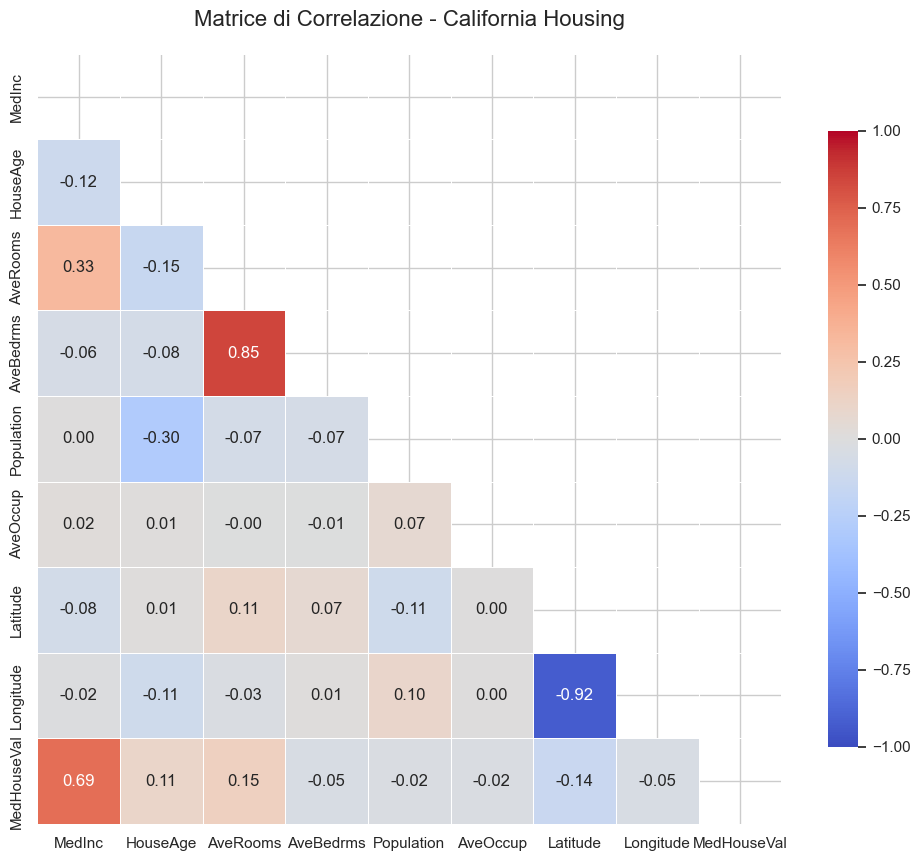

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di correlazione
# Usiamo il metodo di Pearson (default)
corr = df.corr()

# 2. Creazione di una "maschera" per nascondere la parte superiore
# Essendo la matrice speculare, vedere entrambi i lati crea solo confusione visiva
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Configurazione del grafico
plt.figure(figsize=(12, 10))

# Disegniamo la heatmap
sns.heatmap(
    corr, 
    mask=mask,          # Nasconde la parte superiore duplicata
    annot=True,         # Scrive i numeri dentro i quadratini
    fmt=".2f",          # Formatta i numeri a 2 decimali
    cmap='coolwarm',    # Colore: rosso (positivo), blu (negativo), bianco (zero)
    vmin=-1, vmax=1,    # Imposta i limiti della scala colorata
    center=0,           # Il centro della scala è lo zero
    linewidths=.5,      # Aggiunge una linea di separazione tra i quadrati
    cbar_kws={"shrink": .8} # Rimpicciolisce la barra dei colori laterale
)

plt.title('Matrice di Correlazione - California Housing', fontsize=16, pad=20)
plt.show()

## Variabili non correlate linearmente o con tanti oulier?

la correlazione di Spearman è un altro tipo di misurazione, per correlazioni non lineari

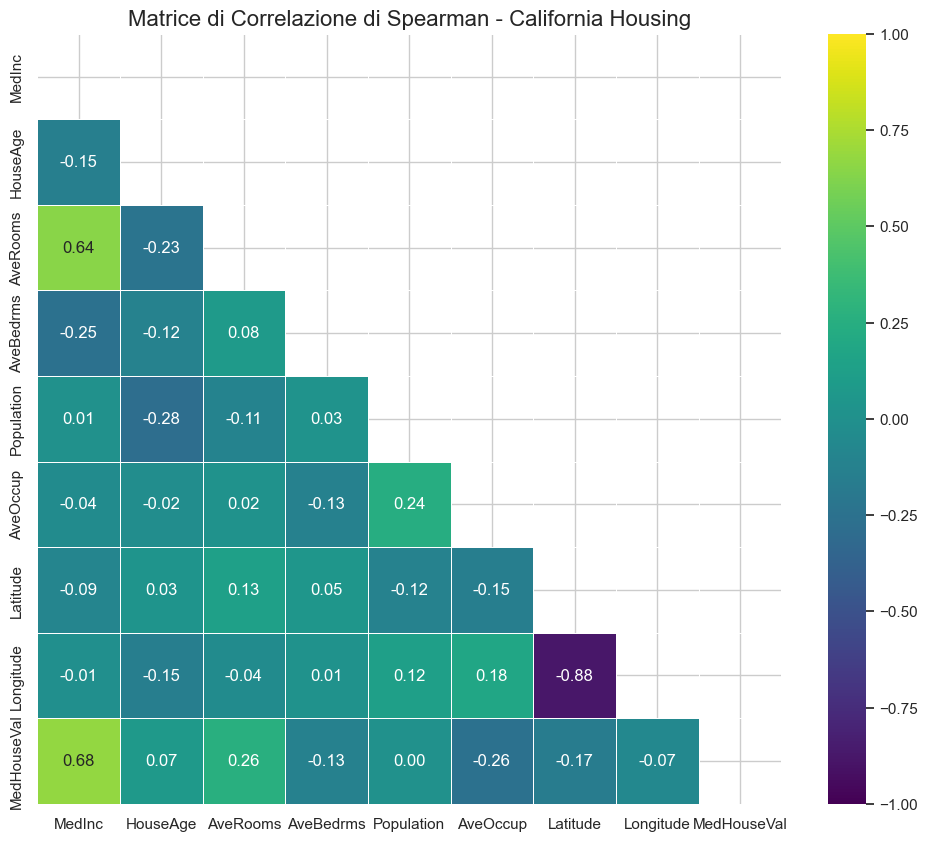

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

# Passo 6: feature engineering

crea nuove frature come combinazioni o modifiche interessanti di feature esistenti. per esempio
- creare raggruppamenti su variabili continue (es. su  HouseAge, 1 gruppo ogni 5 anni e vedere se ci sono pattern oppure soglie di valore per MedInc per definire soglie di ceto basso, medio, ricco per vedere se cambiano alcuni pattern)
- variabili come divisione di feature esistenti (AveOccup/AveRooms, case con tot stanze per tot persone fa cambiare i prezzi)
- variabili al quadrato per eventuali relazioni non lineari (vedendo la matrice di sperman potrei provare ad usare AveRooms al quadrato)
- variabili derivare da conoscenza del settore, soprattutto in casi medici (con altezza e peso, posso vedere l'indice di massa corporea ad esempio, per info medice)

Correlazione di Spearman con il Target (MedHouseVal):
MedHouseVal         1.000000
Income_Class        0.625628
AveRooms_Squared    0.263367
HouseAge_Group      0.075584
Occup_per_Room     -0.399798
Name: MedHouseVal, dtype: float64


C:\Users\ilari\AppData\Local\Temp\ipykernel_30308\2585107523.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')


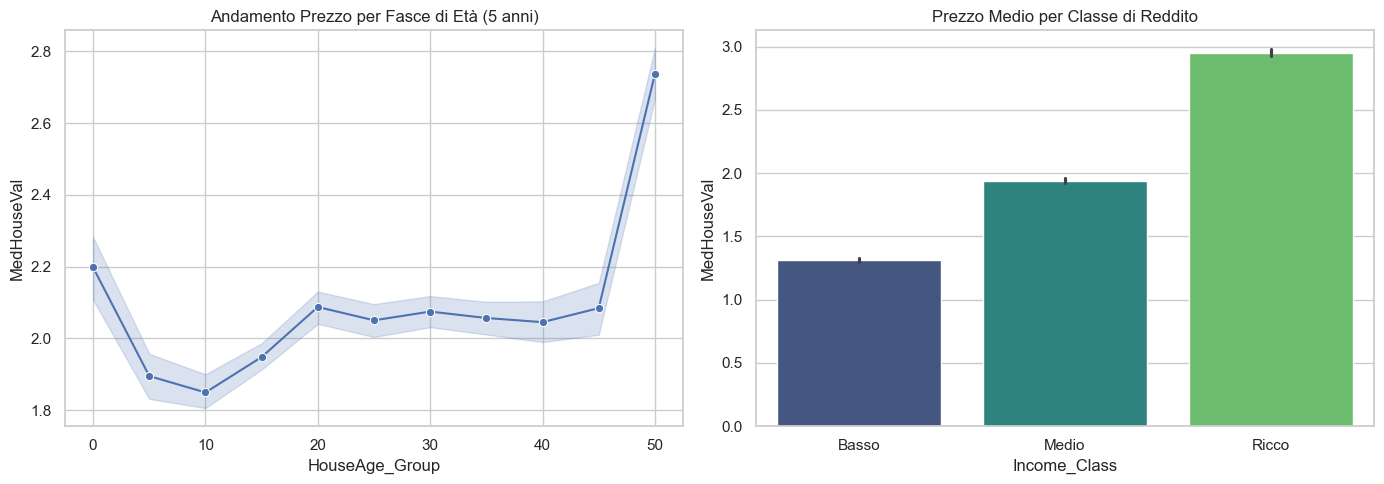

In [13]:
# --- FEATURE ENGINEERING ---

# A. Raggruppamento HouseAge (ogni 5 anni)
# Creiamo etichette numeriche basate sul limite inferiore del gruppo (0, 5, 10...)
df['HouseAge_Group'] = pd.cut(df['HouseAge'], 
                              bins=range(0, 56, 5), 
                              labels=range(0, 55, 5)).astype(float)

# B. Soglie di valore su MedInc (Ceto Basso, Medio, Ricco)
# Usiamo i quartili per definire le classi in modo bilanciato
df['Income_Class'] = pd.qcut(df['MedInc'], q=3, labels=[1, 2, 3]) 
# 1: Basso, 2: Medio, 3: Ricco (manteniamo numerico per la correlazione)

# C. Rapporto tra feature esistenti (Affollamento per stanza)
# Un valore alto indica potenzialmente zone più povere o popolose
df['Occup_per_Room'] = df['AveOccup'] / df['AveRooms']

# D. Variabile al quadrato (Relazione non lineare per AveRooms)
df['AveRooms_Squared'] = df['AveRooms'] ** 2

# --- CALCOLO CORRELAZIONI ---

# Selezioniamo le nuove feature e il target
new_features = ['HouseAge_Group', 'Income_Class', 'Occup_per_Room', 'AveRooms_Squared', 'MedHouseVal']
corr_matrix = df[new_features].astype(float).corr(method='spearman')

print("Correlazione di Spearman con il Target (MedHouseVal):")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))

# --- VISUALIZZAZIONE PATTERN ---

plt.figure(figsize=(14, 5))

# Plot 1: Andamento Prezzo vs Età Casa (Binned)
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='HouseAge_Group', y='MedHouseVal', marker='o')
plt.title('Andamento Prezzo per Fasce di Età (5 anni)')

# Plot 2: Prezzo Medio per Classe di Reddito
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')
plt.xticks([0, 1, 2], ['Basso', 'Medio', 'Ricco'])
plt.title('Prezzo Medio per Classe di Reddito')

plt.tight_layout()
plt.show()

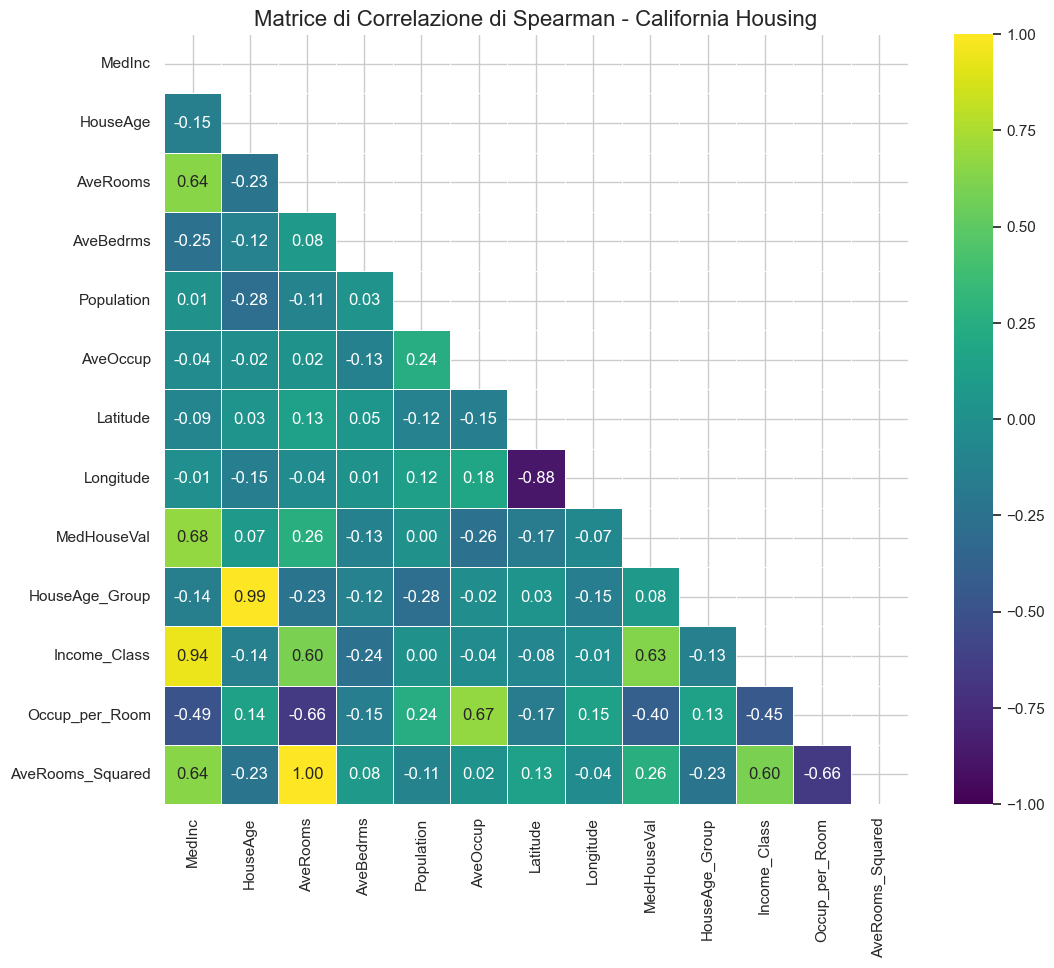

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# 2. Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

# Passo 7: normalizzazione

bisogna normalizzare i dati per evitare che valori enormi come 5mln per i prezzi vadano ad annientare valori piu piccoli come il numero di stanze nelle case

se devo minimizzare un errore e cambiando due valori ottengo

- un errore piu basso di 2 punti sul numero di stanze (media 5.5)
- un errore piu basso di 1000 euro sul valore di una cassa (2 mlm)

il miglior miglioramento, con un approccio relativo, è quello sul numero di istanze, ma matematicamente parlando 1000 è meglio di 2, dobbiamo evitare questa confusione al modello

ci sono 2 tecniche



## 1. MinMaxScaler (Normalizzazione)

Trasforma i dati in un intervallo fisso, solitamente **[0, 1]**.


$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

* **Pro:** Mantiene esattamente la relazione tra i dati.
* **Contro:** È **estremamente sensibile agli outlier**. Se hai un solo valore enorme (es. una casa con 100 stanze), schiaccerà tutti gli altri valori vicini allo zero.

## 2. StandardScaler (Standardizzazione)

Trasforma i dati in modo che abbiano **Media = 0** e **Deviazione Standard = 1**.


$$z = \frac{x - \mu}{\sigma}$$

* **Pro:** È più robusto in presenza di outlier rispetto al Min-Max e rende i coefficienti dei modelli lineari più facili da interpretare.
* **Contro:** Non garantisce un range fisso (i valori possono andare oltre -3 o +3).

Tranne rare eccezioni di base si usa sempre lo standardScaler. (eccezioni per le immagini, dove i pixel vanno da 0 a 255)

In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.datasets import fetch_california_housing

# 1. Prepariamo i dati
data = fetch_california_housing(as_frame=True)
X = data.frame[['MedInc', 'HouseAge', 'Population']] # Prendiamo 3 variabili con scale diverse

# 2. Inizializziamo gli Scaler
min_max = MinMaxScaler()
standard = StandardScaler()

# 3. Trasformazione
X_minmax = min_max.fit_transform(X)
X_standard = standard.fit_transform(X)

# Creiamo un DataFrame per confrontare i risultati sulla prima riga
comparison = pd.DataFrame({
    'Originale': X.iloc[0],
    'Min-Max [0, 1]': X_minmax[0],
    'Standard (z-score)': X_standard[0]
})

print("Confronto Scaler sulla prima riga del dataset:")
print(comparison)

Confronto Scaler sulla prima riga del dataset:
            Originale  Min-Max [0, 1]  Standard (z-score)
MedInc         8.3252        0.539668            2.344766
HouseAge      41.0000        0.784314            0.982143
Population   322.0000        0.008941           -0.974429


# DOMANDE

## 1

1. Il reddito medio (MedInc) sembra il predittore più forte. Ma un reddito alto in una zona desertica vale quanto lo stesso reddito a San Francisco? Quale altra variabile potresti 'mescolare' con il reddito per capire meglio la capacità di acquisto in quella zona?



Statistiche Population:
count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: Population, dtype: float64


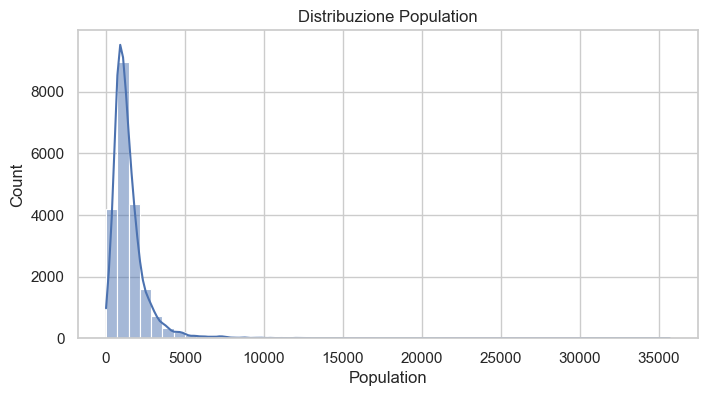


Soglia Population (10% più basso): 510.0
Numero zone isolate: 2066


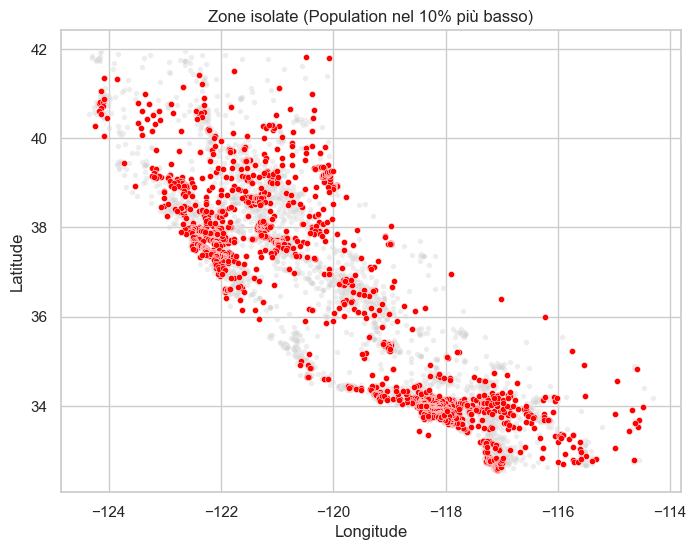


Statistiche MedInc nelle zone isolate:
count    2066.000000
mean        3.826949
std         2.332347
min         0.499900
25%         2.290275
50%         3.289600
75%         4.701225
max        15.000100
Name: MedInc, dtype: float64


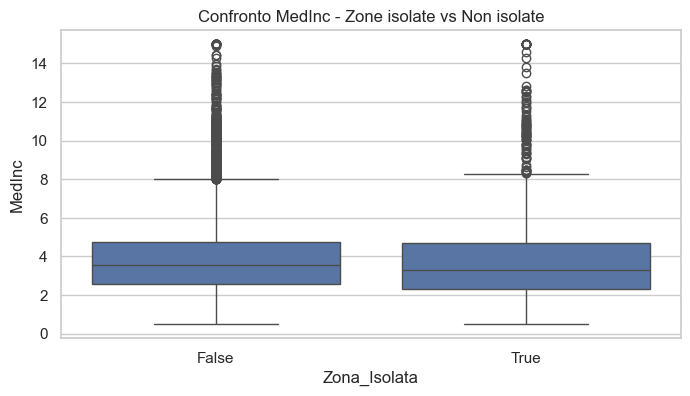

In [16]:
 
# ===============================
# ANALISI ZONE ISOLATE (Population)
# ===============================

# 1. Analizziamo la distribuzione della popolazione
print("Statistiche Population:")
print(df["Population"].describe())

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,4))
sns.histplot(df["Population"], bins=50, kde=True)
plt.title("Distribuzione Population")
plt.show()


# 2. Definiamo come "zone isolate" il 10% con popolazione più bassa
soglia_isolata = df["Population"].quantile(0.10)

zone_isolate = df[df["Population"] <= soglia_isolata]

print("\nSoglia Population (10% più basso):", soglia_isolata)
print("Numero zone isolate:", len(zone_isolate))


# 3. Visualizziamo sulla mappa (Latitudine / Longitudine)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Longitude", y="Latitude",
                color="lightgray", alpha=0.4, s=15)

sns.scatterplot(data=zone_isolate,
                x="Longitude", y="Latitude",
                color="red", s=20)

plt.title("Zone isolate (Population nel 10% più basso)")
plt.show()


# 4. Analizziamo il reddito medio nelle zone isolate
print("\nStatistiche MedInc nelle zone isolate:")
print(zone_isolate["MedInc"].describe())


# 5. Confronto MedInc: isolate vs resto

df["Zona_Isolata"] = df["Population"] <= soglia_isolata

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Zona_Isolata", y="MedInc")
plt.title("Confronto MedInc - Zone isolate vs Non isolate")
plt.show()

# 2 

2. Se dividete il reddito in 10 gruppi (decili), il prezzo delle case sale sempre della stessa quantità tra un gruppo e l'altro? O c'è un punto in cui, anche se il reddito raddoppia, il prezzo della casa smette di salire drasticamente?

Come interpretare il risultato

- Se gli incrementi sono simili → crescita quasi lineare.
- Se gli incrementi si riducono negli ultimi decili → effetto saturazione.
- Se l’ultimo decile mostra un forte aumento ma poi si stabilizza → possibile cap del dataset (ricorda che MedHouseVal è limitato a 5.0 nel dataset originale).

Prezzo medio per decile di reddito:
MedInc_Decile
0    1.101797
1    1.266338
2    1.477231
3    1.663145
4    1.862524
5    2.015082
6    2.207469
7    2.393294
8    2.799943
9    3.899877
Name: MedHouseVal, dtype: float64


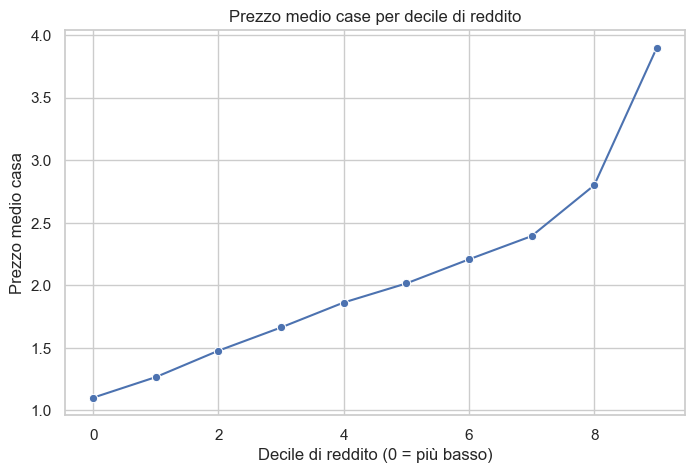


Incremento medio tra decili consecutivi:
MedInc_Decile
0         NaN
1    0.164541
2    0.210894
3    0.185913
4    0.199380
5    0.152557
6    0.192387
7    0.185825
8    0.406650
9    1.099933
Name: MedHouseVal, dtype: float64


In [17]:
# ===============================
# ANALISI PER DECILI DI REDDITO
# ===============================

# 1. Creiamo i decili di reddito
df["MedInc_Decile"] = pd.qcut(df["MedInc"], 10, labels=False)

# 2. Calcoliamo prezzo medio per ogni decile
prezzo_medio_decili = df.groupby("MedInc_Decile")["MedHouseVal"].mean()

print("Prezzo medio per decile di reddito:")
print(prezzo_medio_decili)


# 3. Visualizzazione andamento

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.lineplot(x=prezzo_medio_decili.index,
             y=prezzo_medio_decili.values,
             marker="o")

plt.xlabel("Decile di reddito (0 = più basso)")
plt.ylabel("Prezzo medio casa")
plt.title("Prezzo medio case per decile di reddito")
plt.show()


# 4. Analizziamo l'incremento tra un decile e l'altro
incrementi = prezzo_medio_decili.diff()

print("\nIncremento medio tra decili consecutivi:")
print(incrementi)

### analisi grafico

Il prezzo medio delle case cresce in modo quasi lineare lungo i primi 8 decili di reddito. Non si osserva una saturazione progressiva. Nell’ultimo decile si nota invece un’accelerazione marcata, segno che le aree con reddito più elevato presentano un salto strutturale nei valori immobiliari, probabilmente legato alla posizione geografica e alla concentrazione di zone ricche.

# 3


3. Ci aspetteremmo che le case più vecchie costino meno. Ma se create dei bin per l'età, i prezzi medi seguono davvero una linea discesa? O c'è un 'ritorno di fiamma' dove le case molto vecchie tornano a costare tanto quanto quelle nuove?



Prezzo medio per fascia di età:
Age_Bin
(0.949, 6.1]    2.162053
(6.1, 11.2]     1.851975
(11.2, 16.3]    1.907387
(16.3, 21.4]    1.941120
(21.4, 26.5]    2.104373
(26.5, 31.6]    2.042390
(31.6, 36.7]    2.075264
(36.7, 41.8]    2.034777
(41.8, 46.9]    2.052642
(46.9, 52.0]    2.532209
Name: MedHouseVal, dtype: float64


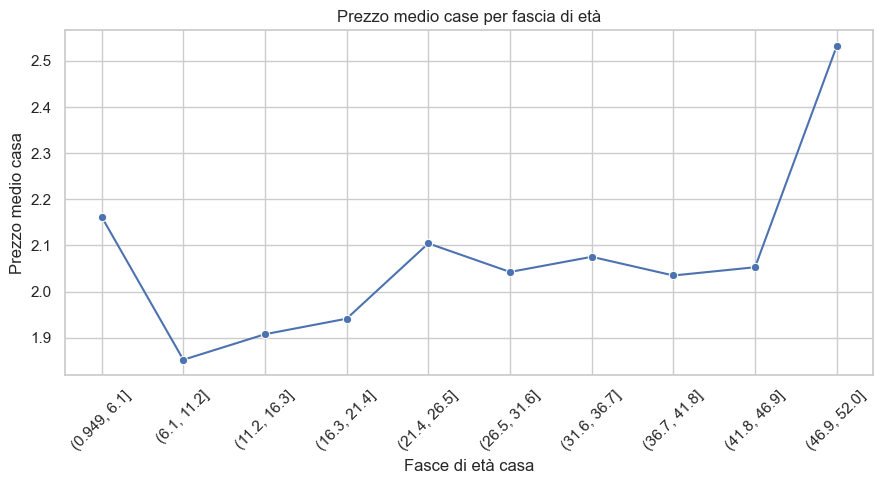

In [18]:
# ===============================
# ANALISI PREZZO vs ETA' CASA
# ===============================

# 1. Creiamo 10 bin di età
df["Age_Bin"] = pd.cut(df["HouseAge"], bins=10)

# 2. Calcoliamo prezzo medio per bin
prezzo_medio_eta = df.groupby("Age_Bin")["MedHouseVal"].mean()

print("Prezzo medio per fascia di età:")
print(prezzo_medio_eta)


# 3. Visualizzazione andamento

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.lineplot(
    x=range(len(prezzo_medio_eta)),
    y=prezzo_medio_eta.values,
    marker="o"
)

plt.xticks(
    ticks=range(len(prezzo_medio_eta)),
    labels=[str(interval) for interval in prezzo_medio_eta.index],
    rotation=45
)

plt.xlabel("Fasce di età casa")
plt.ylabel("Prezzo medio casa")
plt.title("Prezzo medio case per fascia di età")
plt.tight_layout()
plt.show()

### analisi grafico

I prezzi medi non seguono una linea di discesa con l’aumentare dell’età. Dopo un calo iniziale nelle case relativamente giovani, i valori si stabilizzano e mostrano un aumento significativo nelle fasce più alte. Si osserva quindi un “ritorno di fiamma”: le case molto vecchie tornano a costare quanto o più delle nuove, probabilmente per effetto della posizione geografica e del valore storico/centrale delle aree in cui si trovano.

ha senso? sì. perche le case "vecchie" non più buone si abbattono, quelle che restano acquisiscono valore storico o perché sono grandi e molto usate. pattern trovato, case vecchie acquisiscono valore

# 4

4. Arrotondate la latitudine e la longitudine all'intero più vicino. Ora calcolate il prezzo medio per ogni 'cella' della scacchiera. Quali celle sono dei deserti economici e quali sono miniere d'oro? Ci sono celle vicine con prezzi opposti?



Prime celle:
   Lat_round  Lon_round  MedHouseVal
0       33.0     -118.0     3.283148
1       33.0     -117.0     1.970557
2       33.0     -116.0     0.762039
3       33.0     -115.0     0.745192
4       34.0     -120.0     3.312366

Statistiche prezzo medio per cella:
count    57.000000
mean      1.263811
std       0.775590
min       0.276995
25%       0.776884
50%       0.922875
75%       1.441400
max       3.378001
Name: MedHouseVal, dtype: float64

Celle deserti economici:
    Lat_round  Lon_round  MedHouseVal
23       36.0     -117.0     0.276995
55       42.0     -121.0     0.421667
24       36.0     -116.0     0.502000
56       42.0     -120.0     0.518000
54       42.0     -122.0     0.538000

Celle miniere d'oro:
    Lat_round  Lon_round  MedHouseVal
18       36.0     -122.0     3.378001
4        34.0     -120.0     3.312366
0        33.0     -118.0     3.283148
25       37.0     -122.0     2.966017
5        34.0     -119.0     2.835985


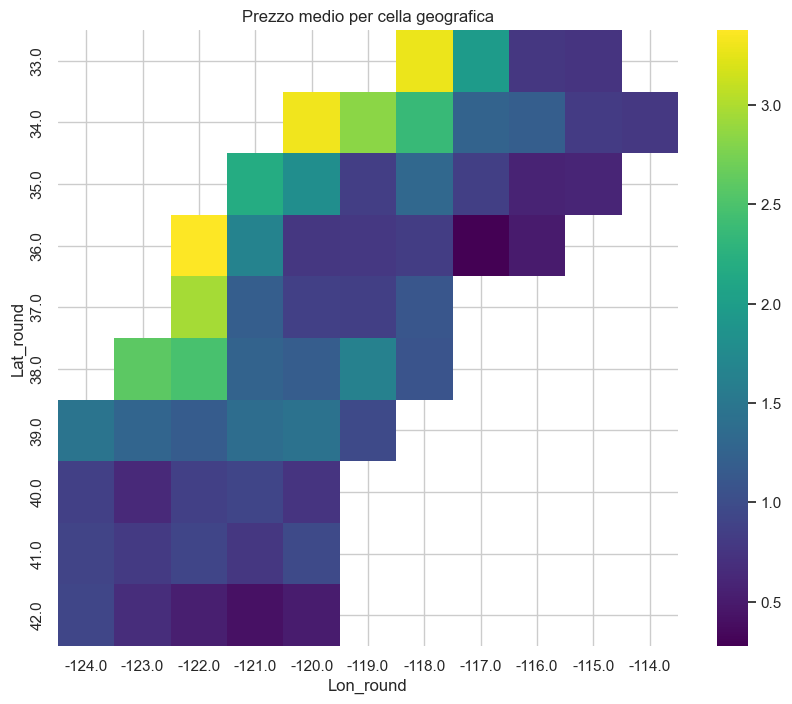

In [19]:
# ===============================
# ANALISI CELLE GEOGRAFICHE
# ===============================

# 1. Arrotondiamo latitudine e longitudine
df["Lat_round"] = df["Latitude"].round()
df["Lon_round"] = df["Longitude"].round()

# 2. Prezzo medio per cella
celle = df.groupby(["Lat_round", "Lon_round"])["MedHouseVal"].mean().reset_index()

print("Prime celle:")
print(celle.head())

print("\nStatistiche prezzo medio per cella:")
print(celle["MedHouseVal"].describe())


# 3. Identifichiamo deserti e miniere (bottom e top 10%)

soglia_bassa = celle["MedHouseVal"].quantile(0.10)
soglia_alta = celle["MedHouseVal"].quantile(0.90)

deserti = celle[celle["MedHouseVal"] <= soglia_bassa]
miniere = celle[celle["MedHouseVal"] >= soglia_alta]

print("\nCelle deserti economici:")
print(deserti.sort_values("MedHouseVal").head())

print("\nCelle miniere d'oro:")
print(miniere.sort_values("MedHouseVal", ascending=False).head())


# 4. Visualizzazione heatmap geografica

import matplotlib.pyplot as plt
import seaborn as sns

pivot = celle.pivot(index="Lat_round", columns="Lon_round", values="MedHouseVal")

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap="viridis")
plt.title("Prezzo medio per cella geografica")
plt.show()

### analidi grafico

Arrotondando latitudine e longitudine emergono celle con forti differenze di prezzo medio. Le “miniere d’oro” si concentrano nelle aree costiere centrali e meridionali (intorno a San Francisco e Los Angeles), con valori superiori a 3.0. I “deserti economici” si trovano invece nelle aree interne e nel nord della California, con prezzi medi inferiori a 1.0. Si osservano inoltre celle geograficamente vicine con prezzi molto diversi, evidenziando un forte effetto della vicinanza alla costa e dei centri urbani.

# 5

5. C'è una relazione tra quanto è 'affollata' una casa e il suo valore? Provate a vedere il prezzo medio per i bin di AveOccup. Notate dei valori estremi (bin con 20+ persone)?


count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64


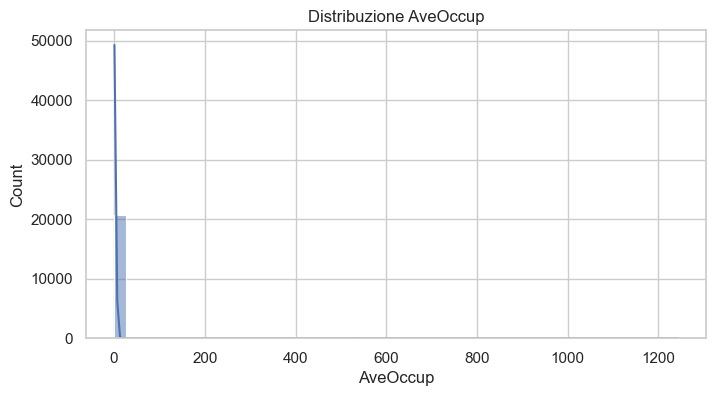


Prezzo medio per fascia di affollamento:
Occup_Bin
(-0.55, 124.956]        2.068581
(124.956, 249.221]      2.250000
(497.749, 622.013]      2.087500
(1119.069, 1243.333]    1.375000
Name: MedHouseVal, dtype: float64


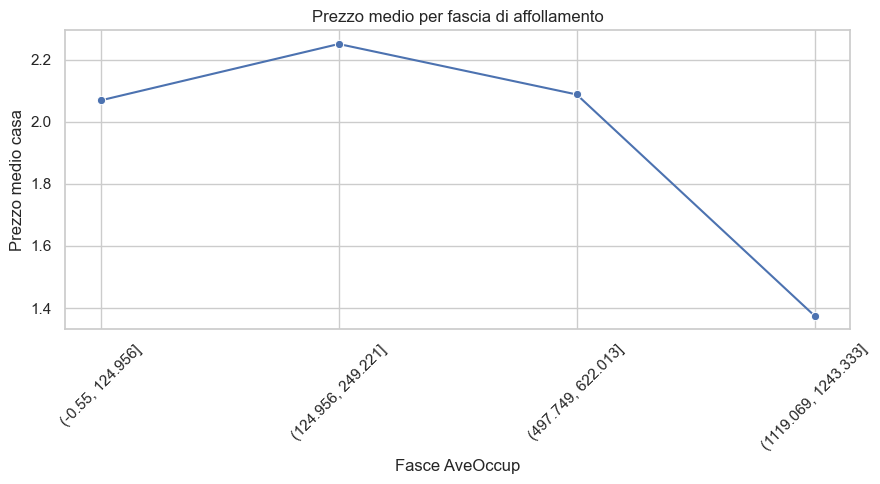

In [20]:
# ===============================
# ANALISI PREZZO vs AFFOLLAMENTO
# ===============================

# 1. Controlliamo distribuzione AveOccup
print(df["AveOccup"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["AveOccup"], bins=50, kde=True)
plt.title("Distribuzione AveOccup")
plt.show()


# 2. Creiamo bin (attenzione: presenza outlier)
df["Occup_Bin"] = pd.cut(df["AveOccup"], bins=10)

prezzo_medio_occup = df.groupby("Occup_Bin")["MedHouseVal"].mean()

print("\nPrezzo medio per fascia di affollamento:")
print(prezzo_medio_occup)


# 3. Visualizzazione andamento

plt.figure(figsize=(9,5))
sns.lineplot(
    x=range(len(prezzo_medio_occup)),
    y=prezzo_medio_occup.values,
    marker="o"
)

plt.xticks(
    ticks=range(len(prezzo_medio_occup)),
    labels=[str(interval) for interval in prezzo_medio_occup.index],
    rotation=45
)

plt.xlabel("Fasce AveOccup")
plt.ylabel("Prezzo medio casa")
plt.title("Prezzo medio per fascia di affollamento")
plt.tight_layout()
plt.show()

### analisi grafici

L’analisi mostra che la distribuzione di AveOccup è fortemente asimmetrica, con la quasi totalità dei valori concentrata su livelli molto bassi e una presenza di outlier estremi che arrivano a valori molto elevati. Questa caratteristica influenza in modo significativo la costruzione dei bin e l’interpretazione del grafico del prezzo medio.

Osservando l’andamento del prezzo medio per fascia di affollamento non emerge una relazione lineare chiara. Si nota che le abitazioni con un livello di affollamento moderato tendono ad avere un prezzo medio leggermente più alto rispetto a quelle con affollamento molto basso, suggerendo che una certa densità abitativa può essere associata a contesti urbani economicamente dinamici. Tuttavia, quando l’affollamento diventa estremo, il prezzo medio cala in modo evidente, indicando che situazioni di sovraffollamento sono associate a contesti economicamente più deboli o a condizioni abitative meno favorevoli.

L’antipattern principale riguarda la presenza di outlier molto elevati che distorcono la suddivisione in bin, creando intervalli troppo ampi e poco interpretabili dal punto di vista economico. Questo rende difficile individuare una relazione strutturale stabile tra affollamento e valore immobiliare. Nel complesso, la relazione esiste ma non è lineare ed è fortemente influenzata da valori estremi che alterano la lettura complessiva del fenomeno.

# 6

6. C'è un altro istogramma, oltre a quello del prezzo, che si interrompe bruscamente con un picco finale. Quale? Cosa succede a una casa che ha 53 o 60 anni in questo dataset? Viene registrata correttamente o finisce in un 'calderone' comune?



### analisi 

Per questa domanda no, non è strettamente necessario aggiungere codice, perché il fenomeno è già evidente dall’istogramma: il picco finale e l’interruzione brusca mostrano chiaramente che la variabile è troncata a 52.
L’altro istogramma che mostra un’interruzione brusca con un picco finale è quello di HouseAge. La distribuzione non si estende in modo naturale oltre un certo valore, ma si ferma improvvisamente a 52 anni, dove compare un accumulo evidente di osservazioni.

Questo comportamento indica che la variabile è stata troncata superiormente. Nel dataset California Housing, 52 rappresenta il valore massimo registrabile per l’età delle case. Di conseguenza, una casa che nella realtà ha 53, 60 o 80 anni non viene registrata con la sua età effettiva, ma viene assegnata al valore 52.

Si crea quindi un “calderone” statistico: tutte le abitazioni con età superiore al limite vengono aggregate nello stesso valore massimo. Questo produce un pattern di censura dei dati, visibile come un picco artificiale nell’istogramma. L’antipattern consiste proprio in questa saturazione del valore massimo, che impedisce di distinguere tra case semplicemente vecchie e case molto vecchie, comprimendo l’informazione nella coda della distribuzione e potenzialmente distorcendo le analisi che coinvolgono l’età come variabile esplicativa.

# 7

7. Sappiamo che San Francisco e Los Angeles sono i poli economici. Se calcolaste la distanza di ogni casa dal centro di queste due città, pensate che questa 'nuova coordinata' spiegherebbe il prezzo meglio della semplice latitudine?



   Latitude  Longitude  Dist_SF_km  Dist_LA_km  Dist_min_km
0     37.88    -122.23   20.329542  556.531199    20.329542
1     37.86    -122.22   19.908065  554.281885    19.908065
2     37.85    -122.24   17.835390  554.612739    17.835390
3     37.85    -122.25   17.064123  555.196283    17.064123
4     37.85    -122.25   17.064123  555.196283    17.064123

Correlazioni con MedHouseVal:
Latitude: -0.14416027687465924
Dist_min_km: -0.4334561113690451
Dist_SF_km: -0.030246886254675538
Dist_LA_km: -0.13067941597097948


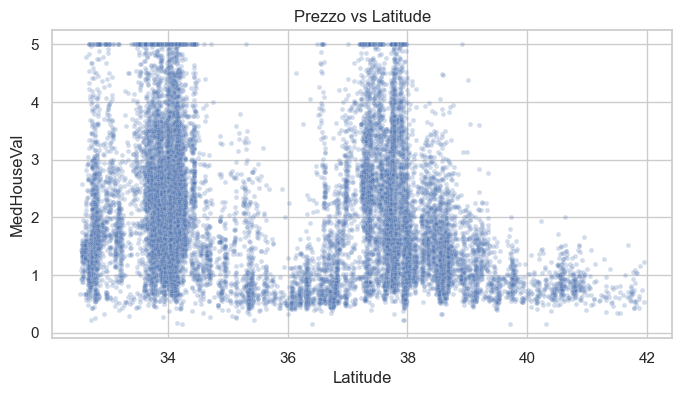

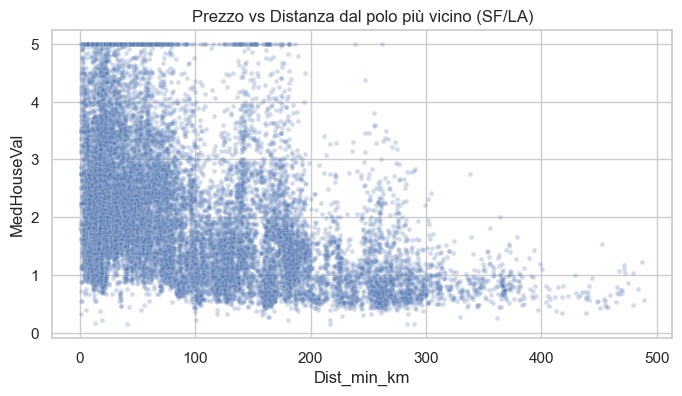


R^2 modello lineare:
Solo Latitude: 0.020782185428578237
Solo Dist_min_km: 0.1878842004831741


In [21]:
# ===============================
# DISTANZA DA SAN FRANCISCO / LOS ANGELES
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Coordinate (circa) dei centri città
SF_LAT, SF_LON = 37.7749, -122.4194
LA_LAT, LA_LON = 34.0522, -118.2437

# Funzione Haversine (distanza su sfera) -> km
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371  # raggio terrestre in km
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 1) Calcolo distanze per ogni casa
df["Dist_SF_km"] = haversine_km(df["Latitude"], df["Longitude"], SF_LAT, SF_LON)
df["Dist_LA_km"] = haversine_km(df["Latitude"], df["Longitude"], LA_LAT, LA_LON)

# Distanza dal polo più vicino
df["Dist_min_km"] = df[["Dist_SF_km", "Dist_LA_km"]].min(axis=1)

print(df[["Latitude", "Longitude", "Dist_SF_km", "Dist_LA_km", "Dist_min_km"]].head())

# 2) Confronto semplice: correlazioni con il prezzo
corr_lat = df["Latitude"].corr(df["MedHouseVal"])
corr_dmin = df["Dist_min_km"].corr(df["MedHouseVal"])
corr_dsf = df["Dist_SF_km"].corr(df["MedHouseVal"])
corr_dla = df["Dist_LA_km"].corr(df["MedHouseVal"])

print("\nCorrelazioni con MedHouseVal:")
print("Latitude:", corr_lat)
print("Dist_min_km:", corr_dmin)
print("Dist_SF_km:", corr_dsf)
print("Dist_LA_km:", corr_dla)

# 3) Grafici: prezzo vs latitudine, prezzo vs distanza minima
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x="Latitude", y="MedHouseVal", alpha=0.25, s=12)
plt.title("Prezzo vs Latitude")
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x="Dist_min_km", y="MedHouseVal", alpha=0.25, s=12)
plt.title("Prezzo vs Distanza dal polo più vicino (SF/LA)")
plt.show()

# 4) Verifica più “comparabile”: modello lineare (R^2) con una feature alla volta
from sklearn.linear_model import LinearRegression

X_lat = df[["Latitude"]]
X_dmin = df[["Dist_min_km"]]
y = df["MedHouseVal"]

mod_lat = LinearRegression().fit(X_lat, y)
mod_dmin = LinearRegression().fit(X_dmin, y)

print("\nR^2 modello lineare:")
print("Solo Latitude:", mod_lat.score(X_lat, y))
print("Solo Dist_min_km:", mod_dmin.score(X_dmin, y))

### analisi grafici

L’analisi visiva mostra una differenza strutturale tra le due variabili.

Nel grafico Prezzo vs Latitude si osservano colonne verticali molto dense, segno che la latitudine da sola non cattura un gradiente economico continuo ma intercetta semplicemente “fasce geografiche”. I prezzi alti si concentrano intorno a determinate latitudini (circa 34 e 37–38), che corrispondono rispettivamente all’area di Los Angeles e della Bay Area, ma la relazione non è monotona: a parità di latitudine esiste una dispersione enorme dei prezzi. Questo indica che la latitudine è una coordinata parziale, incapace di distinguere tra costa ed entroterra.

Nel grafico Prezzo vs Distanza dal polo più vicino emerge invece una struttura più interpretabile. Si nota una concentrazione di prezzi elevati quando la distanza è bassa, e una progressiva riduzione del valore medio all’aumentare della distanza. La relazione non è perfettamente lineare, ma il trend decrescente è più leggibile rispetto al caso della latitudine. Inoltre, la varianza dei prezzi tende a ridursi man mano che ci si allontana dai poli economici, suggerendo un effetto di “raffreddamento” del mercato immobiliare con la distanza.

Il pattern principale è quindi una relazione negativa tra distanza dai poli economici e valore immobiliare: più una casa è vicina a San Francisco o Los Angeles, maggiore è la probabilità che abbia un prezzo elevato. Questo riflette un meccanismo economico reale legato a concentrazione di lavoro, servizi e domanda abitativa.

L’antipattern della latitudine è la presenza di cluster verticali che non rappresentano una relazione funzionale ma solo un effetto geometrico. Un possibile antipattern anche nella distanza è che essa considera solo due poli e potrebbe sottostimare l’influenza di altre aree economicamente rilevanti come San Diego o Sacramento. Tuttavia, rispetto alla latitudine, la distanza dal polo più vicino sembra catturare in modo più diretto il gradiente economico che guida il prezzo.

# 8

8. Se una casa ha un AveOccup di 1.5 persone e un'altra di 6 persone, quale vi aspettereste che costi di più? Ora verificate nei dati: la vostra intuizione regge o i dati vi stanno dicendo che troppa gente in poco spazio 'affonda' il valore dell'immobile?

ps. verrà usata una tolleranza perchè è improbabile trovare esattamente 1.5 o 6

Numero case gruppo 1.5: 473
Numero case gruppo 6: 38

Prezzo medio AveOccup ~1.5: 2.6953419661733617
Prezzo medio AveOccup ~6: 1.6885526315789472


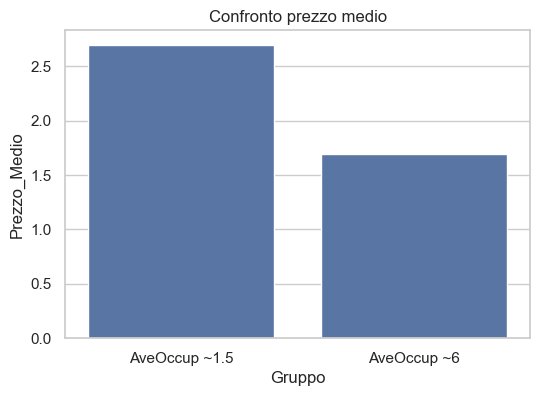

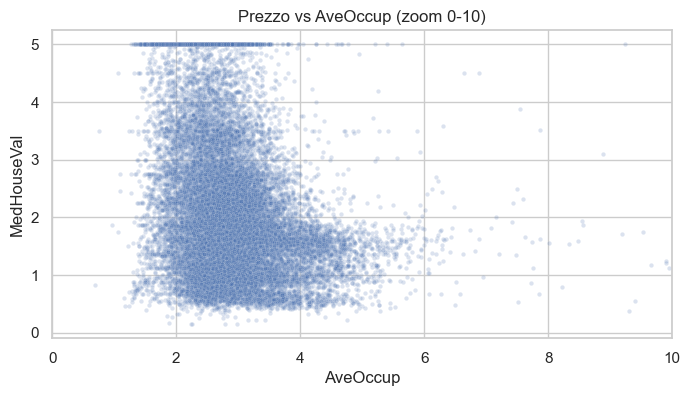

In [22]:
# ===============================
# CONFRONTO AveOccup 1.5 vs 6
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo due gruppi con una piccola tolleranza
tolleranza = 0.2

gruppo_basso = df[(df["AveOccup"] >= 1.5 - tolleranza) & 
                   (df["AveOccup"] <= 1.5 + tolleranza)]

gruppo_alto = df[(df["AveOccup"] >= 6 - tolleranza) & 
                  (df["AveOccup"] <= 6 + tolleranza)]

print("Numero case gruppo 1.5:", len(gruppo_basso))
print("Numero case gruppo 6:", len(gruppo_alto))

# 2. Prezzo medio nei due gruppi
media_basso = gruppo_basso["MedHouseVal"].mean()
media_alto = gruppo_alto["MedHouseVal"].mean()

print("\nPrezzo medio AveOccup ~1.5:", media_basso)
print("Prezzo medio AveOccup ~6:", media_alto)

# 3. Confronto visivo
df_temp = pd.DataFrame({
    "Gruppo": ["AveOccup ~1.5", "AveOccup ~6"],
    "Prezzo_Medio": [media_basso, media_alto]
})

plt.figure(figsize=(6,4))
sns.barplot(data=df_temp, x="Gruppo", y="Prezzo_Medio")
plt.title("Confronto prezzo medio")
plt.show()

# 4. Contesto più ampio: andamento continuo
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x="AveOccup", y="MedHouseVal", alpha=0.2, s=10)
plt.xlim(0, 10)  # limitiamo per leggibilità
plt.title("Prezzo vs AveOccup (zoom 0-10)")
plt.show()

### analisi grafici

L’intuizione iniziale potrebbe essere che una casa con meno persone al suo interno sia più “spaziosa” e quindi più costosa rispetto a una molto affollata. I dati confermano questa aspettativa. Il confronto diretto tra le abitazioni con AveOccup intorno a 1.5 e quelle intorno a 6 mostra una differenza netta: le prime hanno un prezzo medio sensibilmente più alto rispetto alle seconde. L’affollamento maggiore è associato a un valore immobiliare più basso.

Osservando lo scatter plot (limitato tra 0 e 10 per leggibilità) emerge un pattern chiaro: per valori di AveOccup compresi tra circa 1 e 3 si concentrano molti degli immobili con prezzi elevati, mentre all’aumentare dell’affollamento il prezzo tende progressivamente a ridursi e la parte alta della distribuzione si dirada. Non è una relazione perfettamente lineare, ma il trend complessivo è decrescente. Questo suggerisce che un numero elevato di persone per abitazione può essere indicatore di spazi più piccoli, minore qualità abitativa o contesti socioeconomici meno favorevoli, tutti fattori che incidono negativamente sul valore.

Un antipattern interessante è che il massimo prezzo (il cap a 5.0) compare quasi esclusivamente nei valori bassi o moderati di AveOccup e praticamente scompare quando l’affollamento supera 4–5 persone. Inoltre, la forte concentrazione di punti tra 2 e 4 persone indica che gran parte del mercato si colloca in questa fascia “normale”, mentre i valori più alti di affollamento rappresentano una coda meno densa e strutturalmente meno pregiata. Nel complesso, i dati suggeriscono che troppa gente in poco spazio tende effettivamente ad “affondare” il valore dell’immobile.